# Build Grouped Trail Data

Combine Michigan DNR trail segments into one record per county and hiking trail name. The grouped GeoParquet file will support trail filtering and mapping in the Streamlit application.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd


DATA_PATH = Path(
    "../data/processed/dnr_up_hiking_segments_clean.parquet"
)
PROCESSED_PATH = Path(
    "../data/processed/dnr_up_hiking_trails_grouped.parquet"
)

trails = gpd.read_parquet(DATA_PATH)

print(f"Rows: {len(trails):,}")
print(f"Columns: {len(trails.columns)}")
print(f"Trail groups: {trails['TrailGroupName'].nunique():,}")
print(f"CRS: EPSG:{trails.crs.to_epsg()}")

Rows: 2,439
Columns: 12
Trail groups: 159
CRS: EPSG:4326


## Group trail segments

In [2]:
def combine_unique(values: pd.Series):
    """Combine unique non-missing values into one readable string."""
    unique_values = sorted(
        {
            str(value).strip()
            for value in values.dropna()
            if str(value).strip()
        }
    )

    return " | ".join(unique_values) if unique_values else pd.NA


grouped_trails = (
    trails.dissolve(
        by="TrailGroupName",
        aggfunc={
            "HikingName": "first",
            "County": "first",
            "FacilityName": combine_unique,
            "SegmentLengthMiles": "sum",
            "SurfaceType": combine_unique,
            "OpenClosedStatusNonmotor": combine_unique,
            "ADAAccessible": combine_unique,
            "TrailAdministrator": combine_unique,
            "OBJECTID": "count",
        },
    )
    .reset_index()
    .rename(
        columns={
            "SegmentLengthMiles": "TrailLengthMiles",
            "SurfaceType": "SurfaceTypes",
            "OpenClosedStatusNonmotor": "TrailStatuses",
            "ADAAccessible": "AccessibilityValues",
            "OBJECTID": "SegmentCount",
        }
    )
)

grouped_trails["LengthCategory"] = pd.cut(
    grouped_trails["TrailLengthMiles"],
    bins=[0, 2, 7, float("inf")],
    labels=["Short", "Medium", "Long"],
    include_lowest=True,
    right=True,
)

final_column_order = [
    "TrailGroupName",
    "HikingName",
    "County",
    "FacilityName",
    "TrailLengthMiles",
    "LengthCategory",
    "SegmentCount",
    "SurfaceTypes",
    "TrailStatuses",
    "AccessibilityValues",
    "TrailAdministrator",
    "geometry",
]

grouped_trails = grouped_trails[final_column_order]

## Validate grouped data

In [3]:
assert len(grouped_trails) == trails["TrailGroupName"].nunique()
assert grouped_trails["TrailGroupName"].is_unique
assert grouped_trails["TrailLengthMiles"].notna().all()
assert grouped_trails["LengthCategory"].notna().all()
assert grouped_trails.geometry.notna().all()
assert grouped_trails.geometry.is_valid.all()
assert grouped_trails.crs == trails.crs

length_counts = (
    grouped_trails["LengthCategory"]
    .value_counts()
    .sort_index()
)

print(f"Rows: {len(grouped_trails):,}")
print(f"Columns: {len(grouped_trails.columns)}")
print(f"CRS: EPSG:{grouped_trails.crs.to_epsg()}")
print(length_counts)

grouped_trails.head()

Rows: 159
Columns: 12
CRS: EPSG:4326
LengthCategory
Short     90
Medium    41
Long      28
Name: count, dtype: int64


,TrailGroupName,HikingName,County,FacilityName,TrailLengthMiles,LengthCategory,SegmentCount,SurfaceTypes,TrailStatuses,AccessibilityValues,TrailAdministrator,geometry
0,Alger | Fox River Pathway,Fox River Pathway,Alger,State Forest,14.345076,Long,11,Dirt Natural,Open,Not Accessible,DNR Parks And Recreation PRD | National Park S...,"MULTILINESTRING ((-86.22663 46.58784, -86.2266..."
1,Alger | Laughing Whitefish Falls - Trails,Laughing Whitefish Falls - Trails,Alger,SPRK422,0.694618,Short,12,Dirt Natural,Open,Not Accessible,DNR Parks And Recreation PRD,"MULTILINESTRING ((-87.06939 46.38376, -87.0693..."
2,Alger | Laughing Whitefish Falls Trails,Laughing Whitefish Falls Trails,Alger,SPRK422,1.880681,Short,5,<NA>,Open,Not Accessible,DNR Parks And Recreation PRD,"MULTILINESTRING ((-87.07365 46.3835, -87.07362..."
3,Alger | North Country Trail,North Country Trail,Alger,SPRK422,95.559970,Long,129,Concrete | Dirt Natural,Open,Not Accessible,DNR Parks And Recreation PRD | National Park S...,"MULTILINESTRING ((-85.93435 46.66256, -85.9341..."
4,Alger | Tyoga Historical Pathway,Tyoga Historical Pathway,Alger,State Forest,1.269936,Short,2,Dirt Natural,Open,Not Accessible,DNR Parks And Recreation PRD,"MULTILINESTRING ((-87.02677 46.5134, -87.02627..."


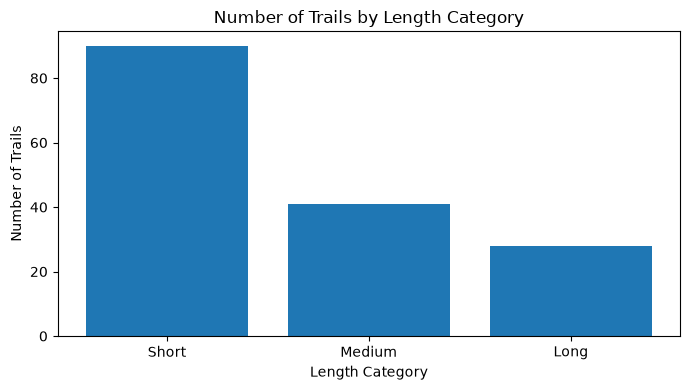

In [4]:
plt.figure(figsize=(7, 4))
plt.bar(length_counts.index.astype(str), length_counts.values)

plt.title("Number of Trails by Length Category")
plt.xlabel("Length Category")
plt.ylabel("Number of Trails")
plt.tight_layout()
plt.show()

## Save processed data

In [5]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

grouped_trails.to_parquet(
    PROCESSED_PATH,
    index=False,
)

print(f"Saved {len(grouped_trails):,} grouped trails to {PROCESSED_PATH}")

Saved 159 grouped trails to ..\data\processed\dnr_up_hiking_trails_grouped.parquet
